In [1]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import torch 
from torch import nn, optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import sklearn
from sklearn.model_selection import train_test_split
import copy
import mytools
import os, random


# Print and store device being used
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


# Define important parameters

In [2]:
# Number of class in invariant mass used by the adversary
Num_classes = 10
# Hyper-parameter for adversarial training of the classifier
lambda_ = 1.0

run = 1


def seed_everything(seed: int = 0):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(int(45))

# Load and setup the data

In [3]:
# Read tritrig, wab, phiKK, and data files
df_tritrig = pd.read_pickle('/Users/mghrear/data/ML_data/patch/2021_v9_pass5_tritrig_QualCuts.pk')
df_tritrig['PhiKK'] = 0.0
df_phiKK = pd.read_pickle('/Users/mghrear/data/ML_data/patch/2021_v9_pass5_phiKK_QualCuts.pk')
df_phiKK['PhiKK'] = 1.0
df_wab = pd.read_pickle('/Users/mghrear/data/ML_data/patch/2021_v9_pass5_wab_QualCuts.pk')
df_wab['PhiKK'] = 0.0 # Add label


print("tritrig: ", len(df_tritrig))
print("phiKK: ", len(df_phiKK))
print("wab: ", len(df_wab))


tritrig:  120352
phiKK:  3845
wab:  6580


In [4]:
# Make Training set with 20000 tritrig, 4000 phiKK, 4000 wab
tritrig_train = df_tritrig[0:20000]
wab_train = df_wab[0:3000]
phiKK_train = df_phiKK[0:3000]

# Combine and shuffle all training data
df_train = pd.concat([tritrig_train, phiKK_train, wab_train], ignore_index=True, sort=False)
df_train = df_train.sample(frac=1, random_state=42).reset_index(drop=True)

# Get edges in invariant mass classes for one-hot encoding
# To be used for adverserial labels
# The edges are chosen such that each bin has equal number of background events
one_hot_edges = mytools.get_one_hot_edges(mytools.get_InvM( pd.concat([df_tritrig, df_wab], ignore_index=True, sort=False) ), n_bins=Num_classes)

# Split the training data into training and validation sets
df_train, df_val = train_test_split(df_train, test_size=0.33, random_state=42)

# Make X and y for training and validation sets
# the adverserial network has its own labels
X_train = df_train.drop(columns=['PhiKK'])
y_train = df_train['PhiKK']
y_adv_train = mytools.get_adv_labels( mytools.get_InvM(df_train), one_hot_edges)
X_val = df_val.drop(columns=['PhiKK'])
y_val = df_val['PhiKK']
y_adv_val = mytools.get_adv_labels( mytools.get_InvM(df_val), one_hot_edges)

# Make testing set with remaining events
tritrig_test = df_tritrig[20000:]
tritrig_test['type']= 'tritrig'
wab_test = df_wab[3000:]
wab_test['type']= 'wab'
phiKK_test = df_phiKK[3000:]
phiKK_test['type']= 'phiKK'

df_test = pd.concat([tritrig_test, phiKK_test,wab_test], ignore_index=True, sort=False)
df_test = df_test.sample(frac=1, random_state=42).reset_index(drop=True) # Now shuffle the combined dataframe

X_test = df_test.drop(columns=['PhiKK','type'])
y_test = df_test['PhiKK']
y_adv_test = mytools.get_adv_labels( mytools.get_InvM(df_test), one_hot_edges)

df_test["InvM"] = mytools.get_InvM(df_test) 



/var/folders/fx/czrkltw953xcpcjd85tf2tmm0000gn/T/ipykernel_78217/1157922432.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tritrig_test['type']= 'tritrig'
/var/folders/fx/czrkltw953xcpcjd85tf2tmm0000gn/T/ipykernel_78217/1157922432.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wab_test['type']= 'wab'
/var/folders/fx/czrkltw953xcpcjd85tf2tmm0000gn/T/ipykernel_78217/1157922432.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_inde

In [5]:
from sklearn.preprocessing import StandardScaler
import joblib

scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_val   = pd.DataFrame(scaler.transform(X_val),       columns=X_val.columns,   index=X_val.index)
X_test  = pd.DataFrame(scaler.transform(X_test),      columns=X_test.columns,  index=X_test.index)

# Save the scaler so it can be applied consistently during inference
joblib.dump(scaler, "/Users/mghrear/data/ML_data/patch/scaler_2021_v9_pass5_run"+str(run)+"_QualCuts.pkl")
print(f"Standardized {X_train.shape[1]} features using training-set statistics.")

Standardized 14 features using training-set statistics.


## Setup dataloaders

In [ ]:
bsize = 2000

# Convert to tensor dataset and dataloader
train_dataset = TensorDataset(torch.from_numpy(X_train.to_numpy().astype(np.float32))  , torch.from_numpy(y_train.to_numpy().astype(np.float32)).unsqueeze(1)  )
train_loader = DataLoader(train_dataset, batch_size=bsize, shuffle=True)

val_dataset = TensorDataset(torch.from_numpy(X_val.to_numpy().astype(np.float32))  , torch.from_numpy(y_val.to_numpy().astype(np.float32)).unsqueeze(1)  )
val_loader = DataLoader(val_dataset, batch_size=bsize, shuffle=True)

test_dataset = TensorDataset(torch.from_numpy(X_test.to_numpy().astype(np.float32)))
test_loader = DataLoader(test_dataset, batch_size=bsize, shuffle=False)


## Initialize model, objective function, and optimizer

In [7]:
clas = mytools.Classifier(in_features=X_train.shape[1]).to(device)
criterion_clas = nn.BCEWithLogitsLoss()
optimizer_clas = optim.Adam(clas.parameters(), lr=1e-2)
scheduler_clas = torch.optim.lr_scheduler.ExponentialLR(optimizer_clas, gamma=1.0)


## Pre-train the classifier

In [8]:
# Implement early stopping in training loop
# Stop if validation loss has not decreased for the last [patience] epochs
# The model with the lowest loss is stored
patience = 10

Training_losses = np.array([])
Validation_losses = np.array([])

epochs = 100
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    
    Training_losses = np.append(Training_losses, mytools.train_clas(train_loader, clas, criterion_clas, optimizer_clas, scheduler_clas, device))
    Validation_losses = np.append(Validation_losses, mytools.validate_clas(val_loader, clas, criterion_clas, device))
    
    # Keep a running copy of the model with the lowest loss
    if Validation_losses[-1] == np.min(Validation_losses):
        final_classifier = copy.deepcopy(clas)
    
    if len(Validation_losses) > patience:
        if np.sum((Validation_losses[-1*np.arange(patience)-1] - Validation_losses[-1*np.arange(patience)-2]) < 0) == 0:
            print("Stopping early!")
            break
            
print("Done!")

Epoch 1
-------------------------------
Training loss: 0.240209
Validation loss: 0.156370 

Epoch 2
-------------------------------
Training loss: 0.048584
Validation loss: 0.080677 

Epoch 3
-------------------------------
Training loss: 0.028684
Validation loss: 0.046748 

Epoch 4
-------------------------------
Training loss: 0.025875
Validation loss: 0.028140 

Epoch 5
-------------------------------
Training loss: 0.023296
Validation loss: 0.032020 

Epoch 6
-------------------------------
Training loss: 0.023425
Validation loss: 0.025627 

Epoch 7
-------------------------------
Training loss: 0.019836
Validation loss: 0.024854 

Epoch 8
-------------------------------
Training loss: 0.017401
Validation loss: 0.020491 

Epoch 9
-------------------------------
Training loss: 0.016512
Validation loss: 0.024572 

Epoch 10
-------------------------------
Training loss: 0.015701
Validation loss: 0.026606 

Epoch 11
-------------------------------
Training loss: 0.014805
Validation los

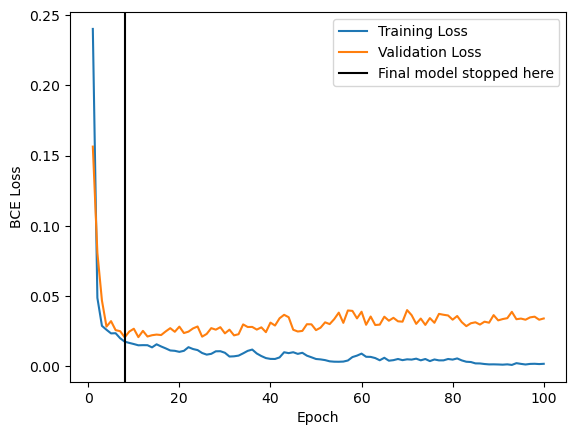

In [9]:
# Plot Training and Validation Loss
# Indicate where the final model stopped training

best_epoch = np.argmin(Validation_losses)+1

plt.plot(np.arange(len(Training_losses))+1,Training_losses,label="Training Loss")
plt.plot(np.arange(len(Validation_losses))+1,Validation_losses,label="Validation Loss")
plt.axvline(best_epoch,label="Final model stopped here",color='k')
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
#plt.yscale('log')
plt.legend()

Test AUROC: 0.9974


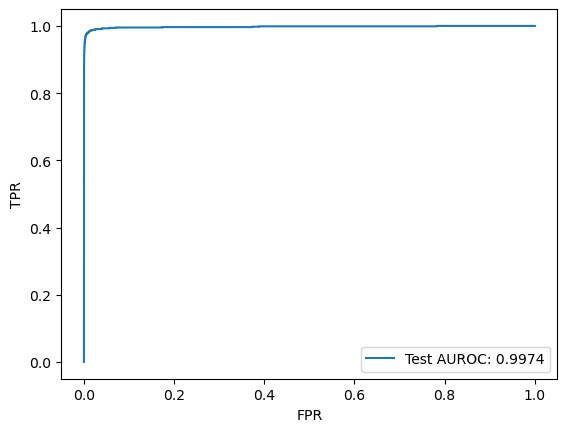

In [10]:
# Now test the pretrained model
test_pred = mytools.test_clas(test_loader, final_classifier, device)
test_pred=torch.sigmoid(torch.tensor(test_pred)).numpy()


fpr, tpr, thresholds = sklearn.metrics.roc_curve(y_test, test_pred, pos_label=1)
auc_test = sklearn.metrics.auc(fpr, tpr)
print(f'Test AUROC: {auc_test:0.4f}')

plt.plot(fpr, tpr, label=f'Test AUROC: {auc_test:0.4f}')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()

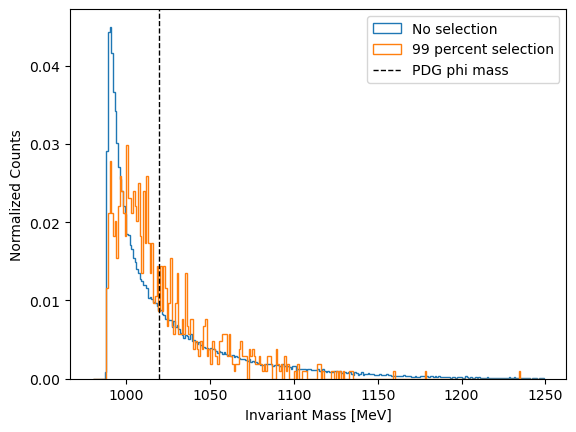

In [12]:
df_test["Class_adv"] = test_pred
df_bkg = df_test.loc[ (df_test.type == 'tritrig') | (df_test.type == 'wab')]
per = np.percentile(df_bkg['Class_adv'],99)
df_cut = df_bkg[df_bkg['Class_adv']>per].reset_index(drop=True)
x_vals = 1000*df_cut.InvM

plt.figure()
plt.hist(1000*df_bkg.InvM, bins=np.arange(980,1250,1), histtype='step', label='No selection', density=True)
plt.hist(x_vals, bins=np.arange(980,1250,1), histtype='step', label= '99 percent selection', density=True)
plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
plt.xlabel('Invariant Mass [MeV]')
plt.ylabel('Normalized Counts')
plt.legend()

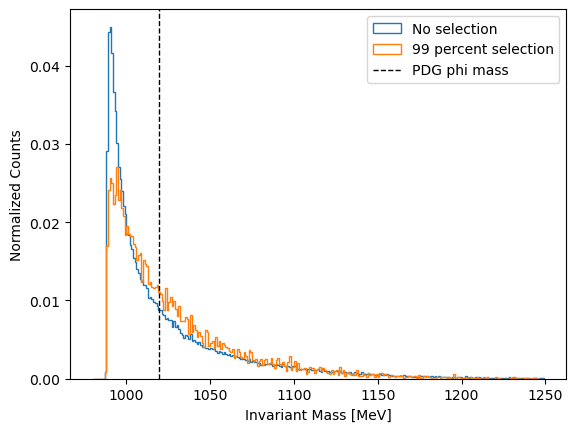

In [13]:
df_test["Class_adv"] = test_pred
df_bkg = df_test.loc[ (df_test.type == 'tritrig') | (df_test.type == 'wab')]
per = np.percentile(df_bkg['Class_adv'],90)
df_cut = df_bkg[df_bkg['Class_adv']>per].reset_index(drop=True)
x_vals = 1000*df_cut.InvM

plt.figure()
plt.hist(1000*df_bkg.InvM, bins=np.arange(980,1250,1), histtype='step', label='No selection', density=True)
plt.hist(x_vals, bins=np.arange(980,1250,1), histtype='step', label= '99 percent selection', density=True)
plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
plt.xlabel('Invariant Mass [MeV]')
plt.ylabel('Normalized Counts')
plt.legend()

In [14]:
# Store the pretrained classifier labels
df_test["Class_pre"] = test_pred

# Save the pretrained classifier model
#torch.save(final_classifier.state_dict(), "/Users/mghrear/data/ML_data/patch/pretrained_classifier_2021_v9_pass5_run"+str(run)+"_limited.pt")


# Setup the adversary model

## Initialize model, objective function, and optimizer

In [15]:
adv = mytools.Adversary_small(n_classes=Num_classes).to(device)
criterion_adv = nn.CrossEntropyLoss(reduction='none')  # returns loss per sample so we can weight it
opt_adv = torch.optim.Adam(adv.parameters(), lr=1e-2)
scheduler_adv = torch.optim.lr_scheduler.ExponentialLR(opt_adv, gamma=1.0)


## Setup dataloaders

In [16]:
# Convert to tensor dataset and dataloader

# the structure is: feature, adversary label, weight
# The wight is 1 for tritrig and wab, and 0 for phiKK, to prevent the adversary from learning on phiKK events

train_adv_dataset = TensorDataset(torch.from_numpy(X_train.to_numpy() .astype(np.float32))  , torch.from_numpy(y_adv_train), (torch.from_numpy(y_train.to_numpy().astype(np.float32))==0).float())
train_adv_loader = DataLoader(train_adv_dataset, batch_size=bsize, shuffle=True)

val_adv_dataset = TensorDataset(torch.from_numpy(X_val.to_numpy() .astype(np.float32))  , torch.from_numpy(y_adv_val), (torch.from_numpy(y_val.to_numpy().astype(np.float32))==0).float() )
val_adv_loader = DataLoader(val_adv_dataset, batch_size=bsize, shuffle=True)

# Weights are not relavent for testing
test_adv_dataset = TensorDataset(torch.from_numpy(X_test.to_numpy() .astype(np.float32))  , torch.from_numpy(y_adv_test))
test_adv_loader = DataLoader(test_adv_dataset, batch_size=bsize, shuffle=True)

## Pre-train the adversary leaving classifier weights fixed

In [17]:
# Implement early stopping in training loop
# Stop if validation loss has not decreased for the last [patience] epochs
# The model with the lowest loss is stored


Training_losses = np.array([])
Validation_losses = np.array([])

epochs = 100
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    
    Training_losses = np.append(Training_losses, mytools.train_adv(train_adv_loader, final_classifier, adv, criterion_adv, opt_adv, scheduler_adv, device))
    Validation_losses = np.append(Validation_losses, mytools.validate_adv(val_adv_loader, final_classifier, adv, criterion_adv, device))
    
    # Keep a running copy of the model with the lowest loss
    if Validation_losses[-1] == np.min(Validation_losses):
        final_adv = copy.deepcopy(adv)

print("Done!")

Epoch 1
-------------------------------
Training loss: 3.395872
Validation loss: 2.976374 

Epoch 2
-------------------------------
Training loss: 2.675450
Validation loss: 2.629035 

Epoch 3
-------------------------------
Training loss: 2.467505
Validation loss: 2.416670 

Epoch 4
-------------------------------
Training loss: 2.359433
Validation loss: 2.323943 

Epoch 5
-------------------------------
Training loss: 2.317095
Validation loss: 2.302745 

Epoch 6
-------------------------------
Training loss: 2.300461
Validation loss: 2.303505 

Epoch 7
-------------------------------
Training loss: 2.290666
Validation loss: 2.290133 

Epoch 8
-------------------------------
Training loss: 2.283748
Validation loss: 2.275364 

Epoch 9
-------------------------------
Training loss: 2.282599
Validation loss: 2.278446 

Epoch 10
-------------------------------
Training loss: 2.275780
Validation loss: 2.278111 

Epoch 11
-------------------------------
Training loss: 2.268569
Validation los

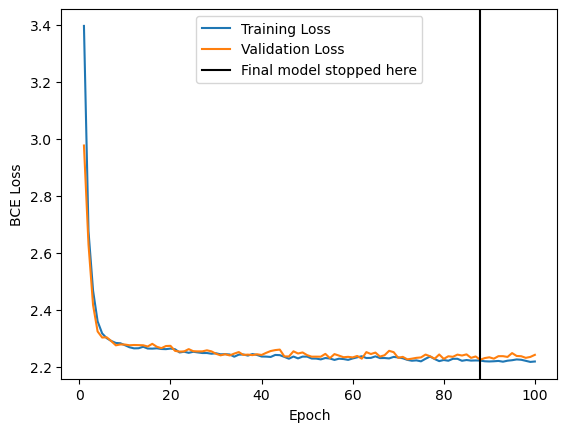

In [18]:
# Plot Training and Validation Loss
# Indicate where the final model stopped training

best_epoch = np.argmin(Validation_losses)+1

plt.plot(np.arange(len(Training_losses))+1,Training_losses,label="Training Loss")
plt.plot(np.arange(len(Validation_losses))+1,Validation_losses,label="Validation Loss")
plt.axvline(best_epoch,label="Final model stopped here",color='k')
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.legend()

## Test the pre-trained adversary

class 0 test auc score: 0.4996648619664911
class 1 test auc score: 0.5013943231380471
class 2 test auc score: 0.5026365409983463
class 3 test auc score: 0.49760275290300876
class 4 test auc score: 0.4947856264832795
class 5 test auc score: 0.4955996189370534
class 6 test auc score: 0.4988814133049196
class 7 test auc score: 0.4924009405598021
class 8 test auc score: 0.5062519180533135
class 9 test auc score: 0.5016154020655832
average score:  0.4990833398409844


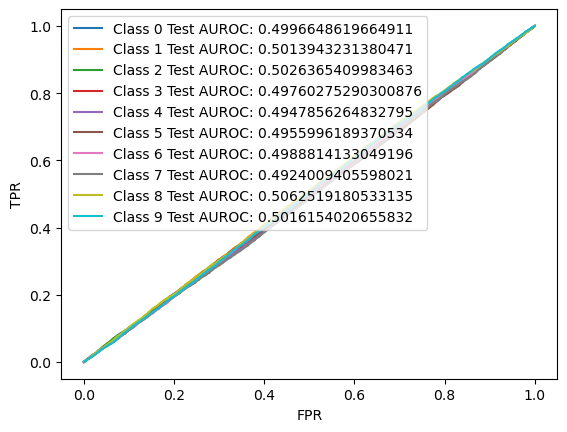

In [19]:

adv_test_pred = mytools.test_adv(test_adv_loader, final_classifier, final_adv, Num_classes, device)
adv_test_pred = torch.softmax(torch.tensor(adv_test_pred),dim=1).numpy()
score=0

for i in range(adv_test_pred.shape[1]):
    fpr, tpr, thresholds = sklearn.metrics.roc_curve(y_adv_test[:,i], adv_test_pred[:,i], pos_label=1)
    auc_test = sklearn.metrics.auc(fpr, tpr)
    print("class " + str(i)+ " test auc score: " + str(auc_test))

    plt.plot(fpr, tpr, label='Class '+str(i)+' Test AUROC: '+str(auc_test))
    plt.xlabel('FPR')
    plt.ylabel('TPR')
    plt.legend()

    score += auc_test

print("average score: ", score/adv_test_pred.shape[1])

# Train full adverserial neural network

# Setup dataloaders

In [20]:
# the structure is: feature, classifier label, adversary label, weight
# The wight is 1 for tritrig and wab, and 0 for phiKK, to prevent the adversary from learning on phiKK events

train_full_dataset = TensorDataset(torch.from_numpy(X_train.to_numpy().astype(np.float32))  , torch.from_numpy(y_train.to_numpy().astype(np.float32)).unsqueeze(1), torch.from_numpy(y_adv_train),  (torch.from_numpy(y_train.to_numpy().astype(np.float32))==0).float())
train_full_loader = DataLoader(train_full_dataset, batch_size=bsize, shuffle=True)

val_full_dataset = TensorDataset(torch.from_numpy(X_val.to_numpy().astype(np.float32))  , torch.from_numpy(y_val.to_numpy().astype(np.float32)).unsqueeze(1),  torch.from_numpy(y_adv_val),  (torch.from_numpy(y_val.to_numpy().astype(np.float32))==0).float())
val_full_loader = DataLoader(val_full_dataset, batch_size=bsize, shuffle=True)


## Define loss functions

In [21]:
BCE_loss = nn.BCEWithLogitsLoss()
CE_loss = nn.CrossEntropyLoss(reduction='none') # returns loss per sample so we can weight it

def full_loss(output_clas, output_adv, target_clas, target_adv, w, lambda_):

    loss1 = BCE_loss(output_clas, target_clas )  # classification loss
    sample_losses2 = CE_loss(output_adv, target_adv)  # adversarial losses, since we set reduction='none', this is now a vector of losses, one per sample in the batch

    # Weighted mean loss over non-zero weights
    nonzero = w > 0
    loss2 = (sample_losses2[nonzero] * w[nonzero]).sum() / w[nonzero].sum()

    loss = loss1 - lambda_*loss2

    return loss
    


## Setup optimizers

In [22]:
optimizer_clas = optim.Adam(final_classifier.parameters(), lr=1e-2,betas=(0.9, 0.999))
optimizer_adv = optim.Adam(final_adv.parameters(), lr=1e-2,betas=(0.9, 0.999))

scheduler_clas = torch.optim.lr_scheduler.ExponentialLR(optimizer_clas, gamma=0.999)
scheduler_adv = torch.optim.lr_scheduler.ExponentialLR(optimizer_adv, gamma=0.999)

## Adversarial training

Epoch 1
-------------------------------
Classifier training loss: -1.940106
Adversary training loss: 2.771886
Classifier validation loss: -2.081872
Adversary validation loss: 2.304272
Diff score: 1.273360


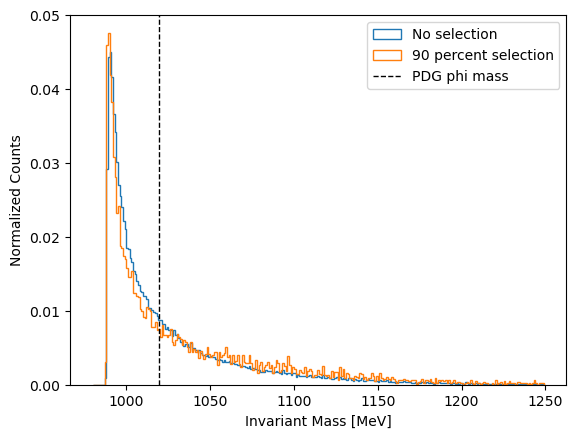

Epoch 2
-------------------------------
Classifier training loss: -2.188265
Adversary training loss: 2.300543
Classifier validation loss: -2.231555
Adversary validation loss: 2.294386
Diff score: 1.105973


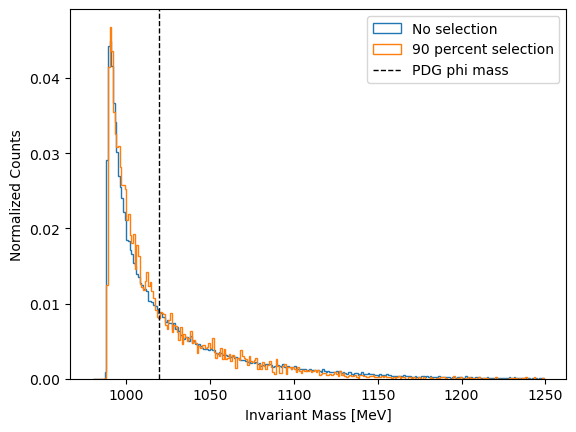

Epoch 3
-------------------------------
Classifier training loss: -2.255958
Adversary training loss: 2.308155
Classifier validation loss: -2.259664
Adversary validation loss: 2.298238
Diff score: 1.086904


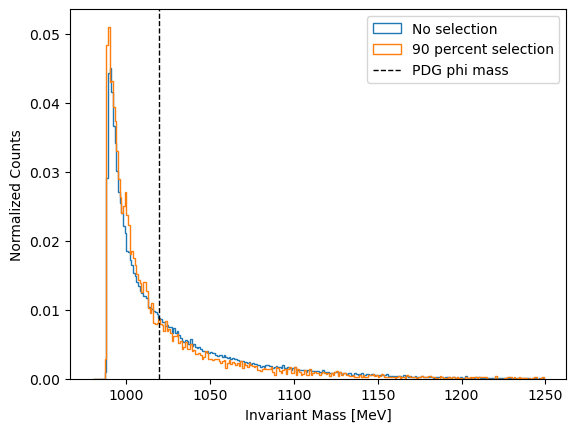

Epoch 4
-------------------------------
Classifier training loss: -2.266927
Adversary training loss: 2.304378
Classifier validation loss: -2.284576
Adversary validation loss: 2.314068
Diff score: 1.415502


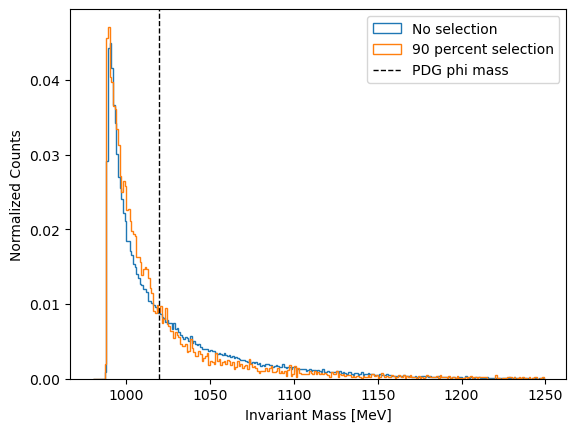

Epoch 5
-------------------------------
Classifier training loss: -2.274640
Adversary training loss: 2.310785
Classifier validation loss: -2.272124
Adversary validation loss: 2.302853
Diff score: 3.208168


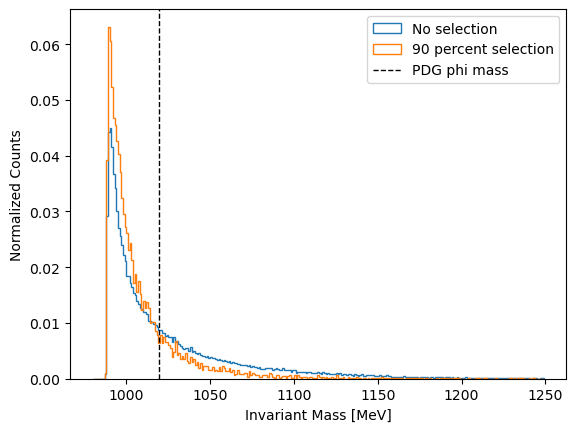

Epoch 6
-------------------------------
Classifier training loss: -2.273472
Adversary training loss: 2.304179
Classifier validation loss: -2.290593
Adversary validation loss: 2.321874
Diff score: 2.065558


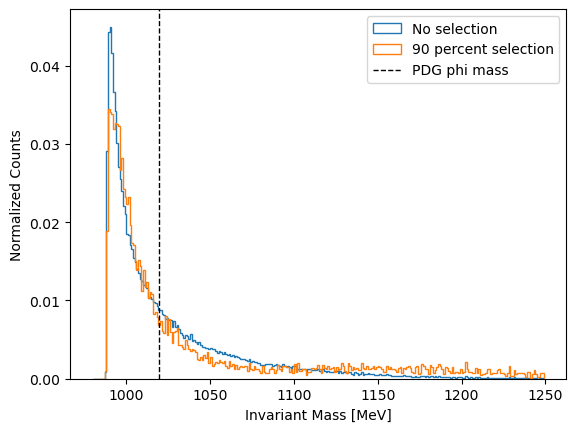

Epoch 7
-------------------------------
Classifier training loss: -2.269064
Adversary training loss: 2.294475
Classifier validation loss: -2.253502
Adversary validation loss: 2.283027
Diff score: 2.086364


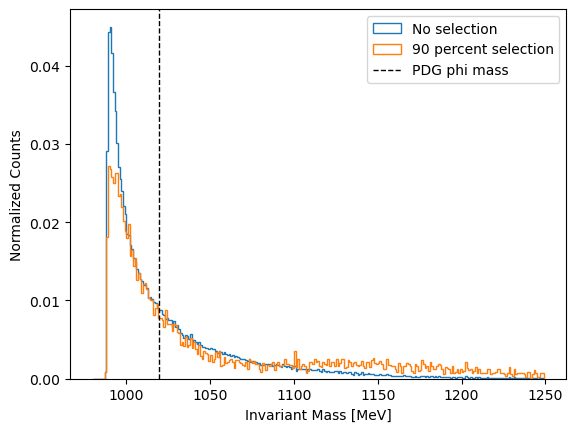

Epoch 8
-------------------------------
Classifier training loss: -2.262418
Adversary training loss: 2.293644
Classifier validation loss: -2.258821
Adversary validation loss: 2.285419
Diff score: 1.533217


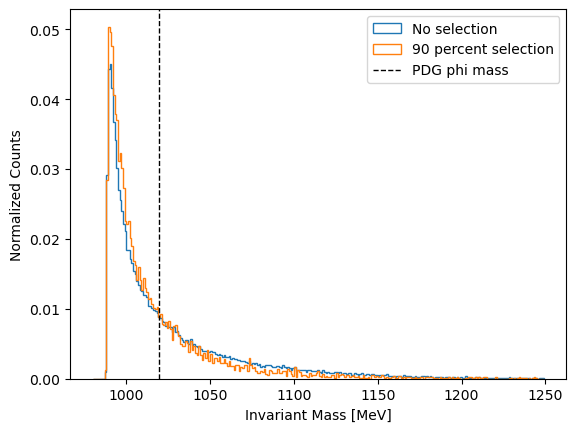

Epoch 9
-------------------------------
Classifier training loss: -2.267319
Adversary training loss: 2.296156
Classifier validation loss: -2.278647
Adversary validation loss: 2.309102
Diff score: 0.974336


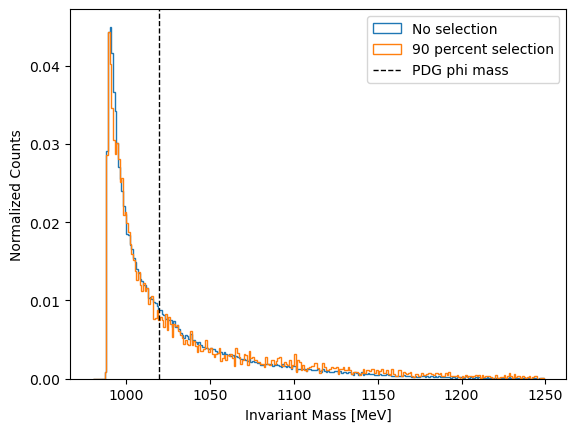

Epoch 10
-------------------------------
Classifier training loss: -2.270613
Adversary training loss: 2.302251
Classifier validation loss: -2.272629
Adversary validation loss: 2.300681
Diff score: 3.392776


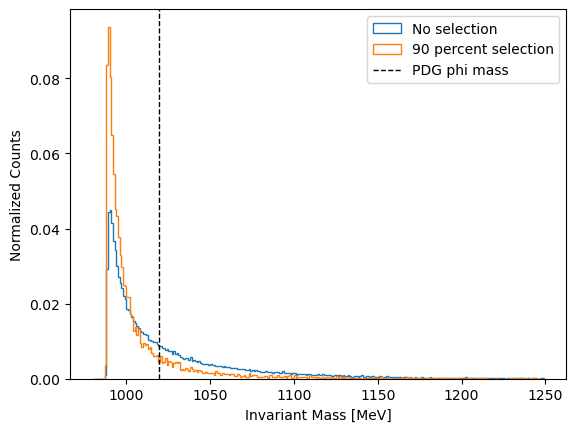

Epoch 11
-------------------------------
Classifier training loss: -2.265839
Adversary training loss: 2.293397
Classifier validation loss: -2.277927
Adversary validation loss: 2.303190
Diff score: 1.395036


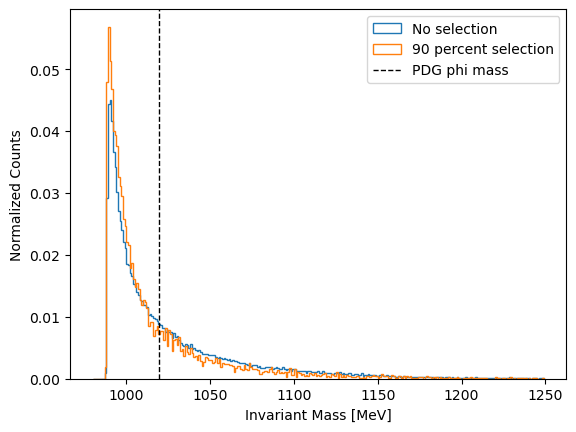

Epoch 12
-------------------------------
Classifier training loss: -2.278614
Adversary training loss: 2.304407
Classifier validation loss: -2.290388
Adversary validation loss: 2.319053
Diff score: 1.183753


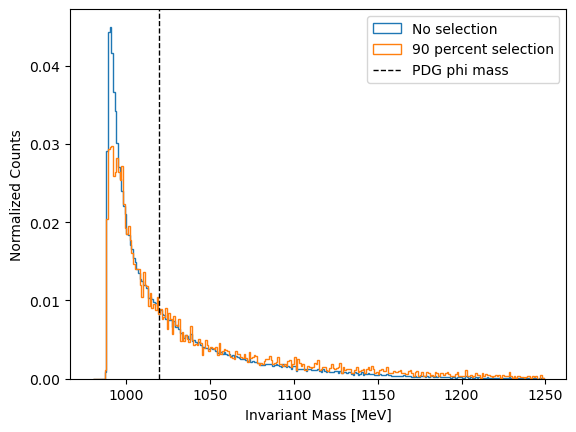

Epoch 13
-------------------------------
Classifier training loss: -2.281586
Adversary training loss: 2.306313
Classifier validation loss: -2.284014
Adversary validation loss: 2.307623
Diff score: 1.124086


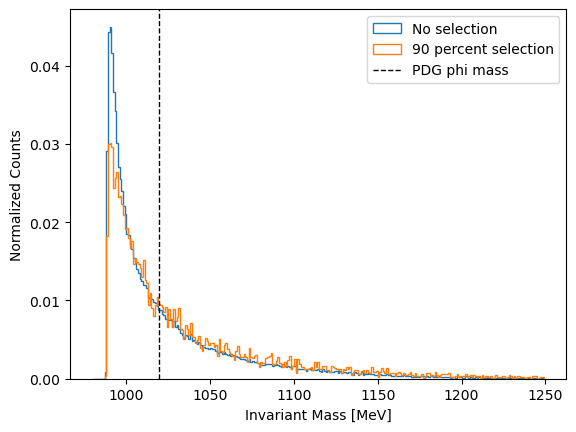

Epoch 14
-------------------------------
Classifier training loss: -2.278867
Adversary training loss: 2.304141
Classifier validation loss: -2.279508
Adversary validation loss: 2.304100
Diff score: 1.020457


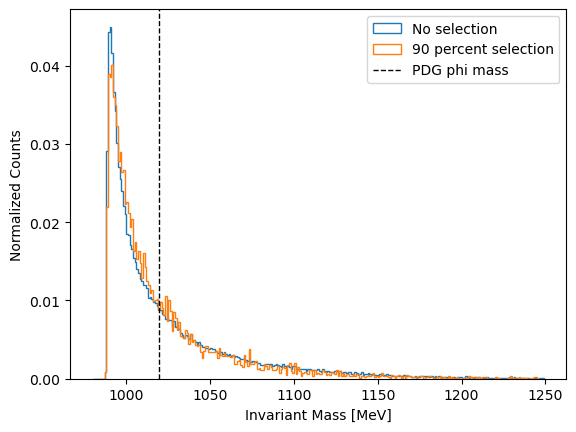

Epoch 15
-------------------------------
Classifier training loss: -2.277317
Adversary training loss: 2.302034
Classifier validation loss: -2.278500
Adversary validation loss: 2.301769
Diff score: 0.828961


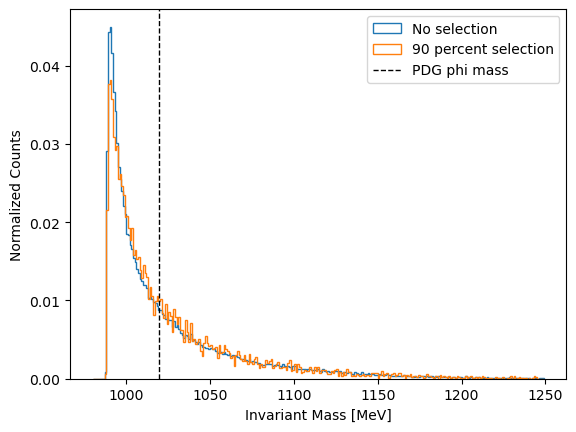

Epoch 16
-------------------------------
Classifier training loss: -2.279183
Adversary training loss: 2.302687
Classifier validation loss: -2.278636
Adversary validation loss: 2.303597
Diff score: 0.792361


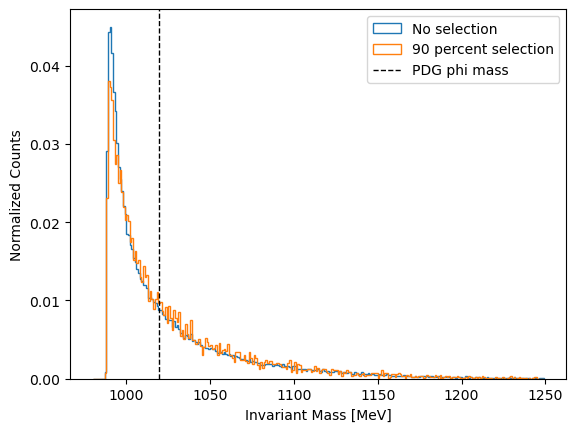

Epoch 17
-------------------------------
Classifier training loss: -2.278680
Adversary training loss: 2.299487
Classifier validation loss: -2.280027
Adversary validation loss: 2.301425
Diff score: 0.851870


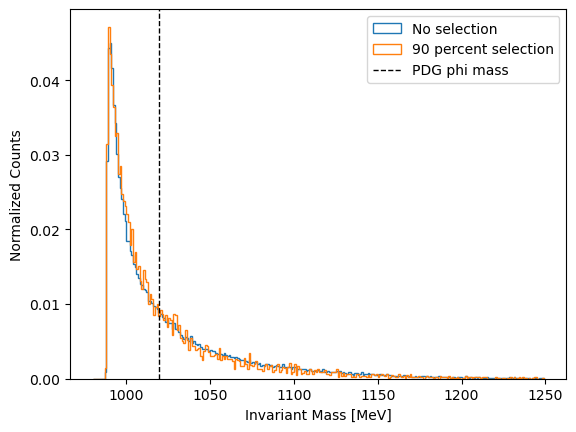

Epoch 18
-------------------------------
Classifier training loss: -2.274998
Adversary training loss: 2.299135
Classifier validation loss: -2.284809
Adversary validation loss: 2.307029
Diff score: 0.805120


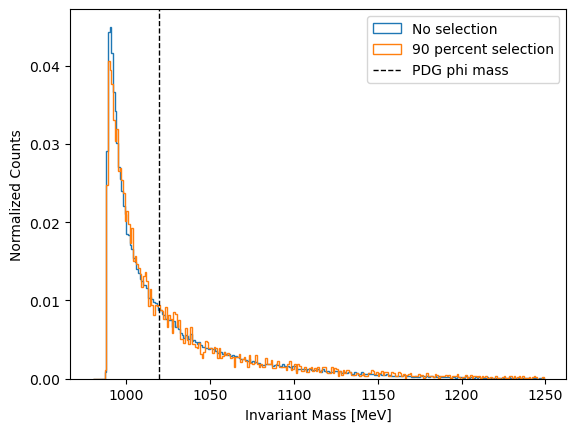

Epoch 19
-------------------------------
Classifier training loss: -2.277084
Adversary training loss: 2.299780
Classifier validation loss: -2.274979
Adversary validation loss: 2.302201
Diff score: 0.826222


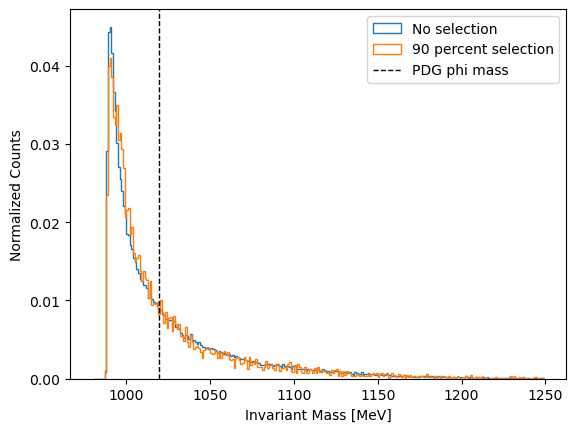

Epoch 20
-------------------------------
Classifier training loss: -2.278355
Adversary training loss: 2.300187
Classifier validation loss: -2.278719
Adversary validation loss: 2.301163
Diff score: 0.882167


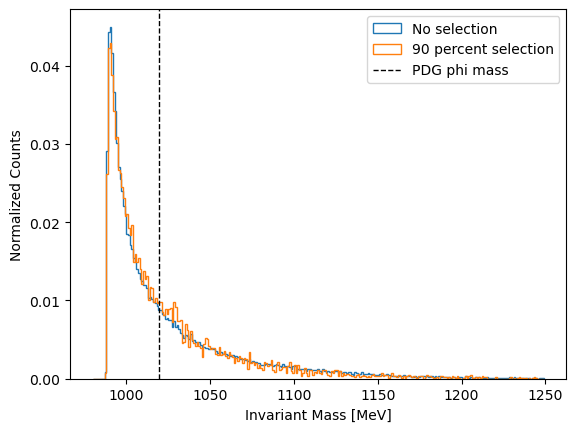

Epoch 21
-------------------------------
Classifier training loss: -2.276748
Adversary training loss: 2.300570
Classifier validation loss: -2.279434
Adversary validation loss: 2.305461
Diff score: 0.851950


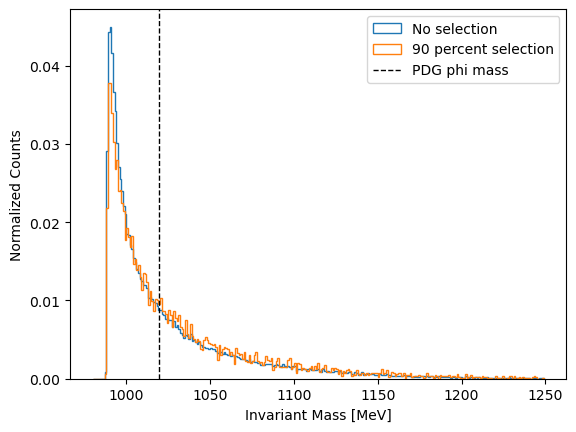

Epoch 22
-------------------------------
Classifier training loss: -2.280793
Adversary training loss: 2.301757
Classifier validation loss: -2.274687
Adversary validation loss: 2.302037
Diff score: 1.077003


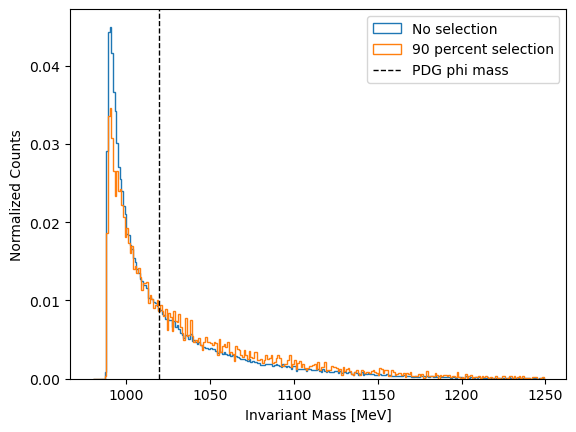

Epoch 23
-------------------------------
Classifier training loss: -2.282533
Adversary training loss: 2.301280
Classifier validation loss: -2.280415
Adversary validation loss: 2.306621
Diff score: 1.034943


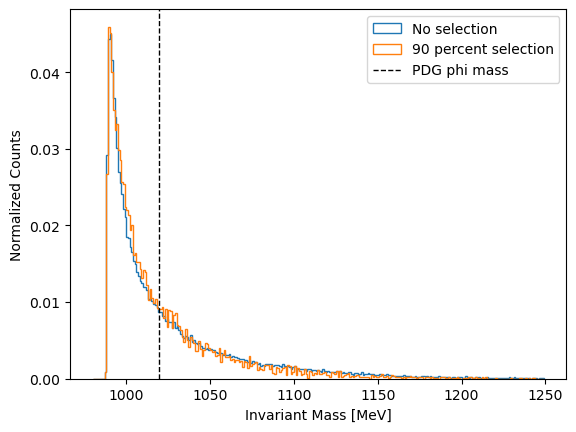

Epoch 24
-------------------------------
Classifier training loss: -2.280958
Adversary training loss: 2.301330
Classifier validation loss: -2.284365
Adversary validation loss: 2.312415
Diff score: 0.761145


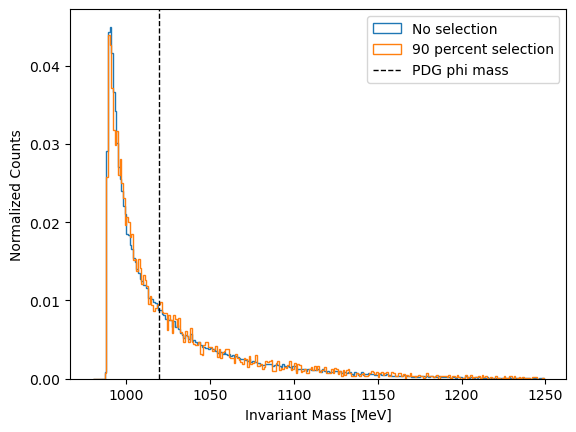

Epoch 25
-------------------------------
Classifier training loss: -2.281463
Adversary training loss: 2.303409
Classifier validation loss: -2.279016
Adversary validation loss: 2.308957
Diff score: 0.995603


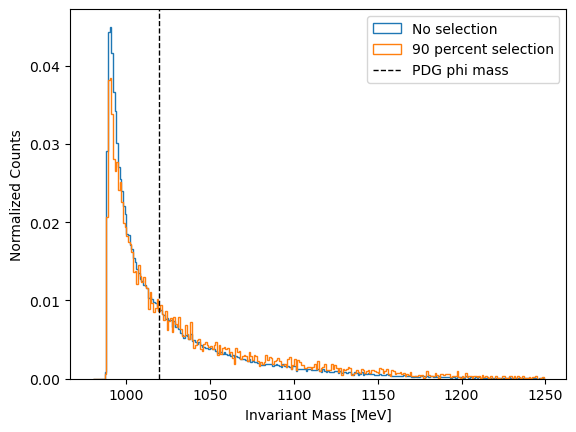

Epoch 26
-------------------------------
Classifier training loss: -2.282291
Adversary training loss: 2.302106
Classifier validation loss: -2.285860
Adversary validation loss: 2.305839
Diff score: 0.787408


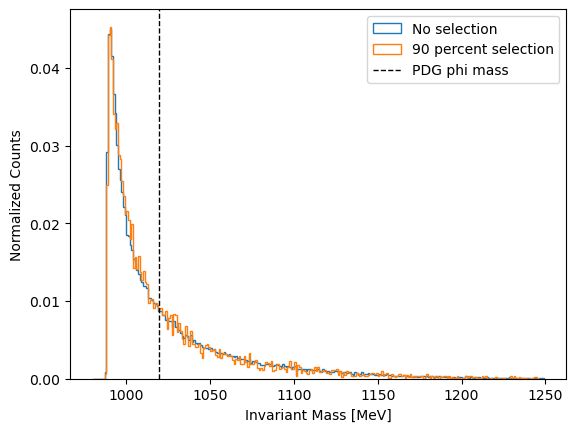

Epoch 27
-------------------------------
Classifier training loss: -2.284143
Adversary training loss: 2.301476
Classifier validation loss: -2.281214
Adversary validation loss: 2.304346
Diff score: 0.776422


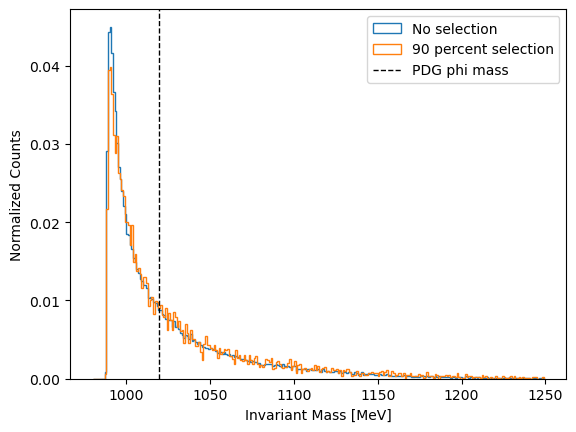

Epoch 28
-------------------------------
Classifier training loss: -2.283705
Adversary training loss: 2.302461
Classifier validation loss: -2.279265
Adversary validation loss: 2.304374
Diff score: 0.873084


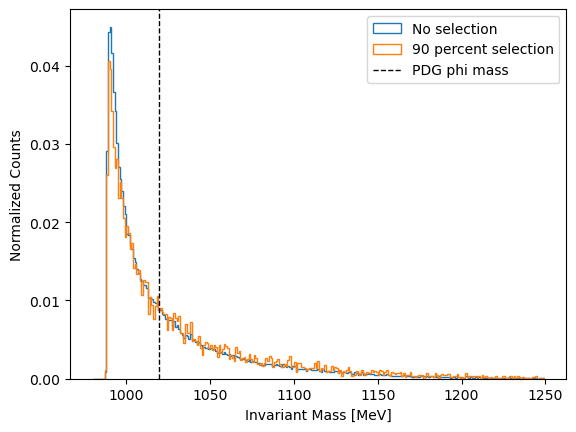

Epoch 29
-------------------------------
Classifier training loss: -2.284868
Adversary training loss: 2.302374
Classifier validation loss: -2.280817
Adversary validation loss: 2.305173
Diff score: 0.834055


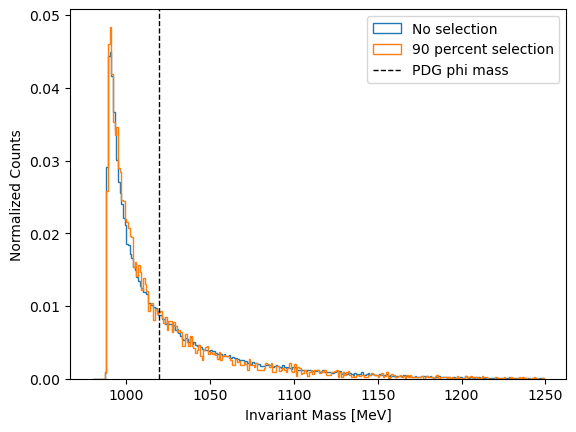

Epoch 30
-------------------------------
Classifier training loss: -2.283269
Adversary training loss: 2.300522
Classifier validation loss: -2.277090
Adversary validation loss: 2.302671
Diff score: 0.797427


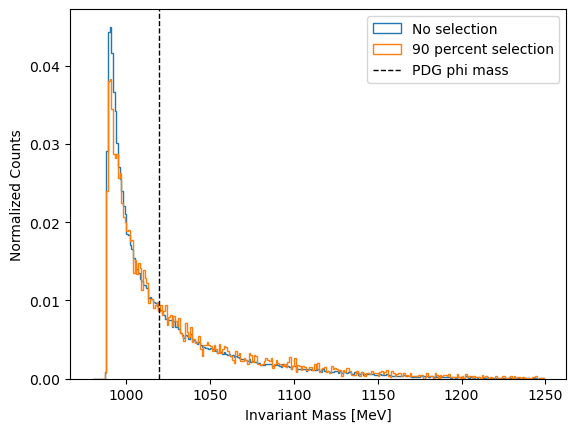

Epoch 31
-------------------------------
Classifier training loss: -2.283779
Adversary training loss: 2.301377
Classifier validation loss: -2.275875
Adversary validation loss: 2.303231
Diff score: 1.354102


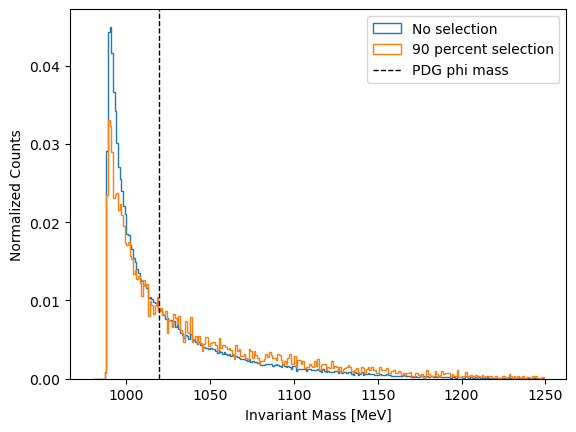

Epoch 32
-------------------------------
Classifier training loss: -2.284185
Adversary training loss: 2.301076
Classifier validation loss: -2.280869
Adversary validation loss: 2.306236
Diff score: 0.749593


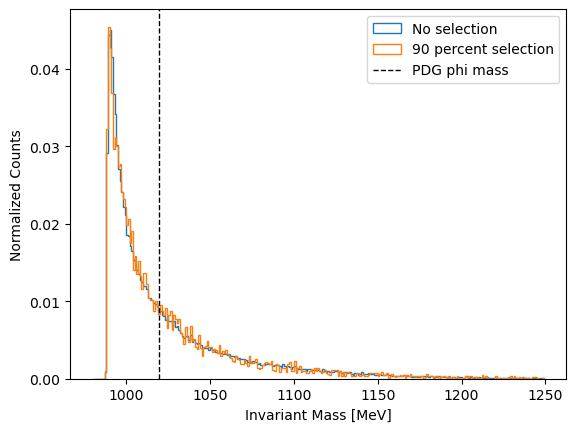

Epoch 33
-------------------------------
Classifier training loss: -2.282110
Adversary training loss: 2.300909
Classifier validation loss: -2.280760
Adversary validation loss: 2.304850
Diff score: 0.810783


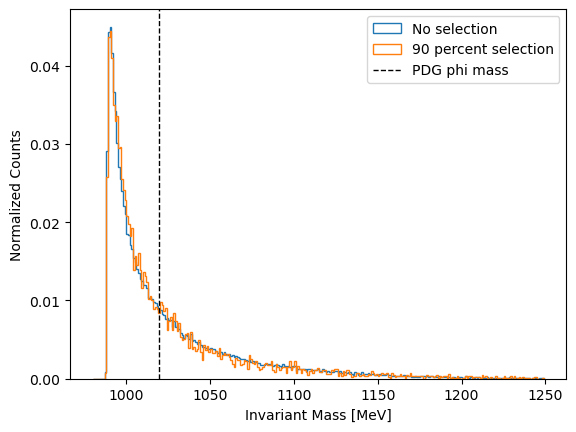

Epoch 34
-------------------------------
Classifier training loss: -2.283931
Adversary training loss: 2.302258
Classifier validation loss: -2.277899
Adversary validation loss: 2.304680
Diff score: 0.925520


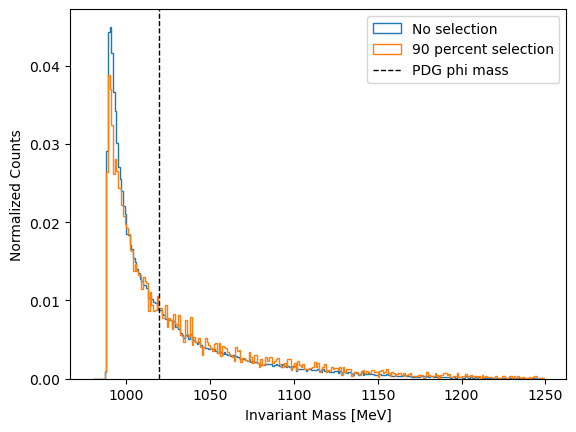

Epoch 35
-------------------------------
Classifier training loss: -2.281827
Adversary training loss: 2.300999
Classifier validation loss: -2.277509
Adversary validation loss: 2.302214
Diff score: 1.084563


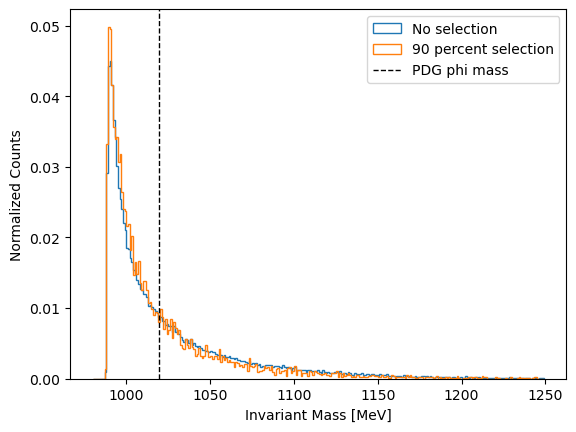

Epoch 36
-------------------------------
Classifier training loss: -2.284679
Adversary training loss: 2.301984
Classifier validation loss: -2.279027
Adversary validation loss: 2.302437
Diff score: 0.762739


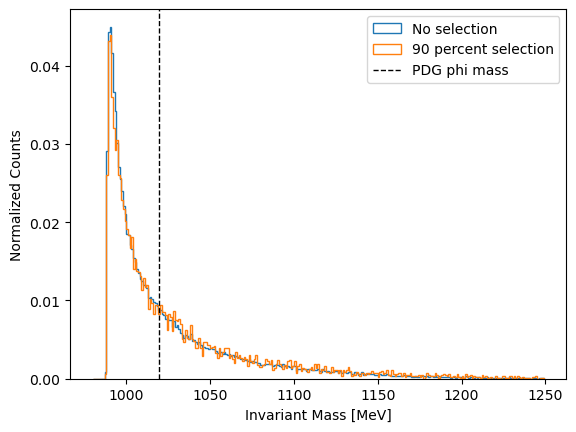

Epoch 37
-------------------------------
Classifier training loss: -2.284770
Adversary training loss: 2.301291
Classifier validation loss: -2.280089
Adversary validation loss: 2.303247
Diff score: 0.894856


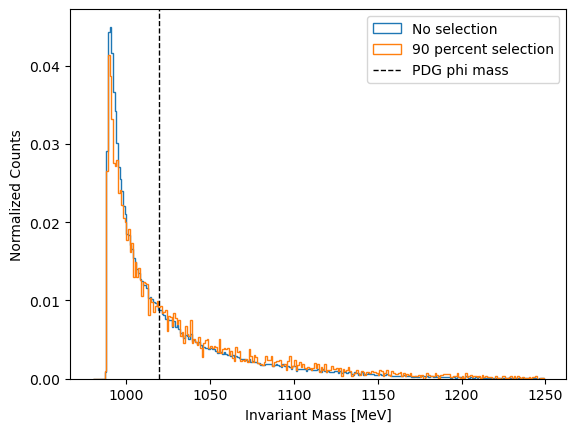

Epoch 38
-------------------------------
Classifier training loss: -2.286759
Adversary training loss: 2.301977
Classifier validation loss: -2.280284
Adversary validation loss: 2.304984
Diff score: 0.718420


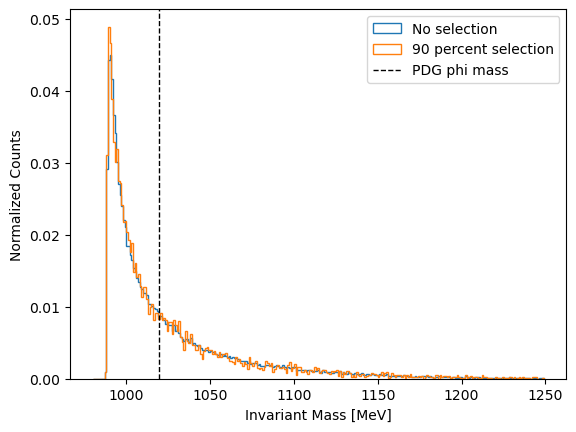

Epoch 39
-------------------------------
Classifier training loss: -2.283218
Adversary training loss: 2.300526
Classifier validation loss: -2.284505
Adversary validation loss: 2.312245
Diff score: 1.060911


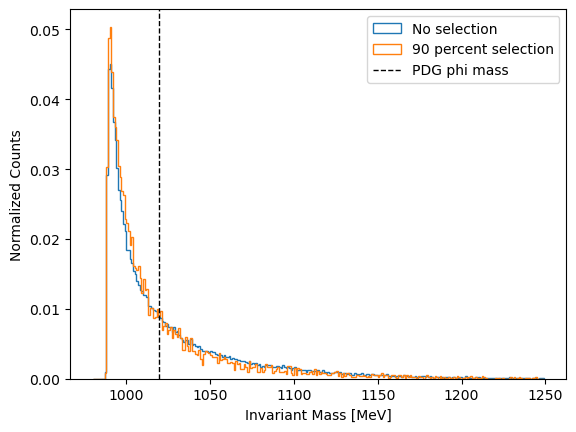

Epoch 40
-------------------------------
Classifier training loss: -2.283904
Adversary training loss: 2.300554
Classifier validation loss: -2.270148
Adversary validation loss: 2.299230
Diff score: 1.403244


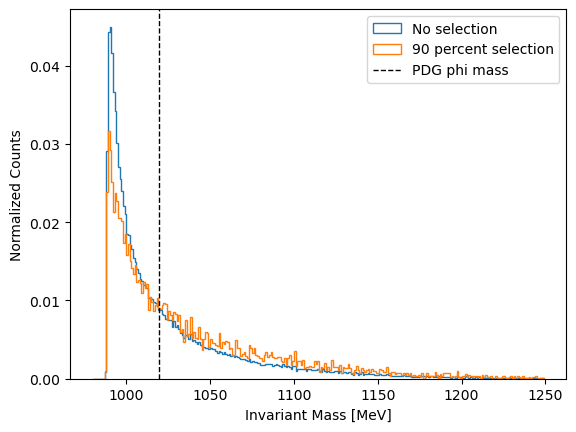

Epoch 41
-------------------------------
Classifier training loss: -2.285313
Adversary training loss: 2.300982
Classifier validation loss: -2.280428
Adversary validation loss: 2.303132
Diff score: 1.166680


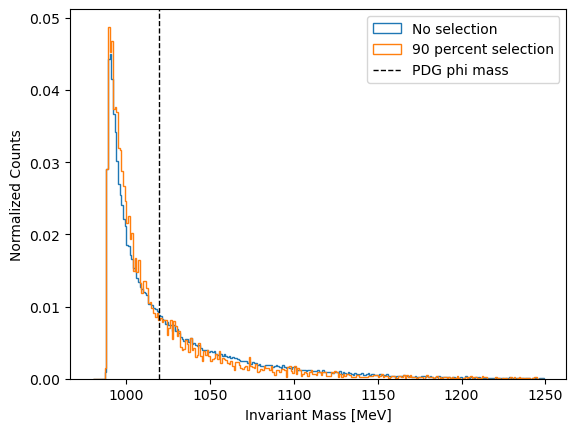

Epoch 42
-------------------------------
Classifier training loss: -2.284457
Adversary training loss: 2.300489
Classifier validation loss: -2.276670
Adversary validation loss: 2.305151
Diff score: 0.808752


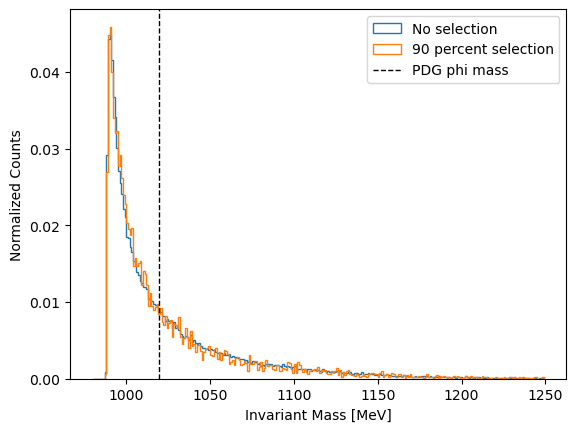

Epoch 43
-------------------------------
Classifier training loss: -2.285302
Adversary training loss: 2.300792
Classifier validation loss: -2.281168
Adversary validation loss: 2.304468
Diff score: 0.807727


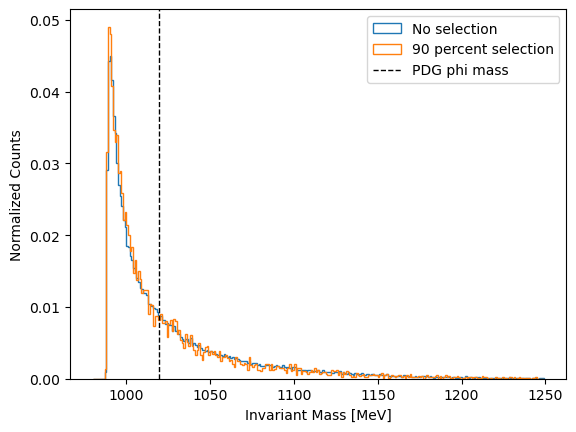

Epoch 44
-------------------------------
Classifier training loss: -2.286008
Adversary training loss: 2.300809
Classifier validation loss: -2.276734
Adversary validation loss: 2.303512
Diff score: 1.229890


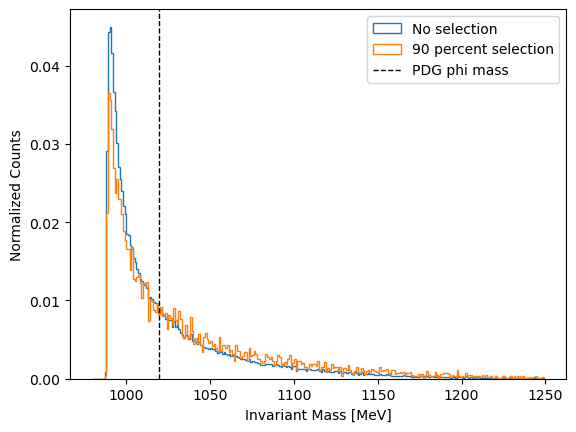

Epoch 45
-------------------------------
Classifier training loss: -2.287129
Adversary training loss: 2.300416
Classifier validation loss: -2.285013
Adversary validation loss: 2.306328
Diff score: 1.185343


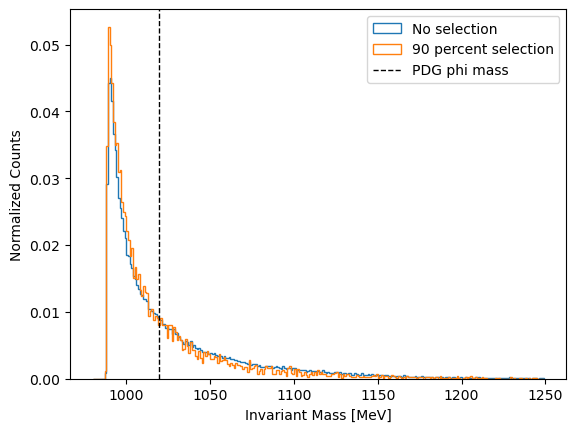

Epoch 46
-------------------------------
Classifier training loss: -2.286606
Adversary training loss: 2.300953
Classifier validation loss: -2.279468
Adversary validation loss: 2.302912
Diff score: 0.752992


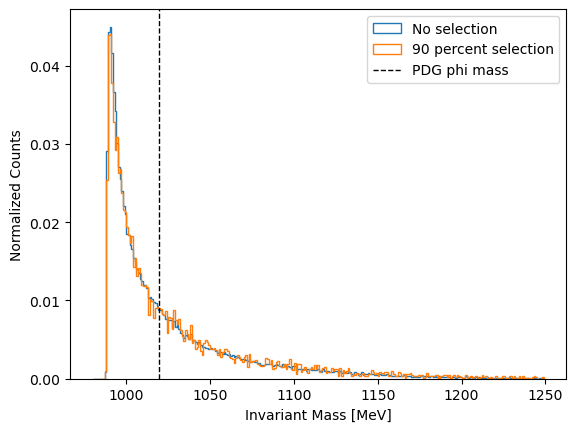

Epoch 47
-------------------------------
Classifier training loss: -2.287449
Adversary training loss: 2.301310
Classifier validation loss: -2.280607
Adversary validation loss: 2.302696
Diff score: 0.796242


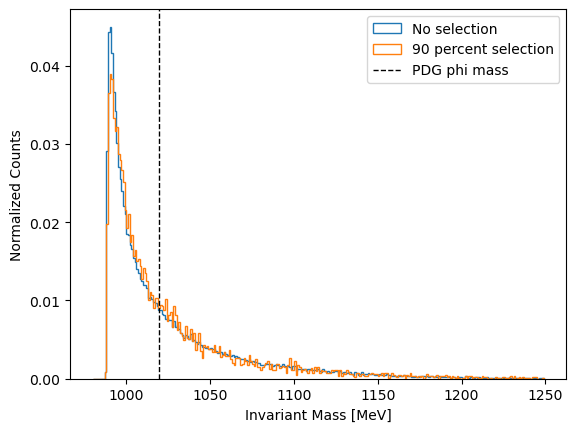

Epoch 48
-------------------------------
Classifier training loss: -2.287724
Adversary training loss: 2.301054
Classifier validation loss: -2.279213
Adversary validation loss: 2.303240
Diff score: 0.742348


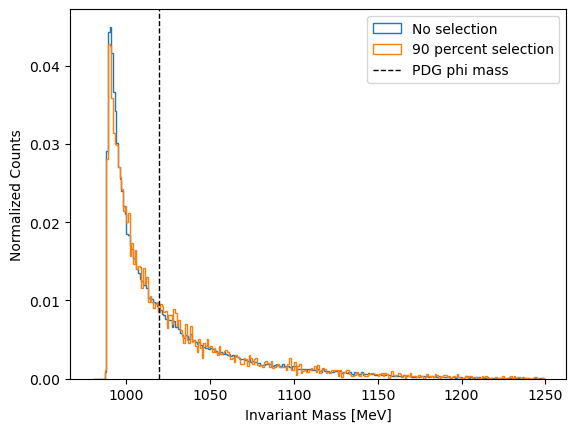

Epoch 49
-------------------------------
Classifier training loss: -2.287998
Adversary training loss: 2.301210
Classifier validation loss: -2.282820
Adversary validation loss: 2.306255
Diff score: 1.407920


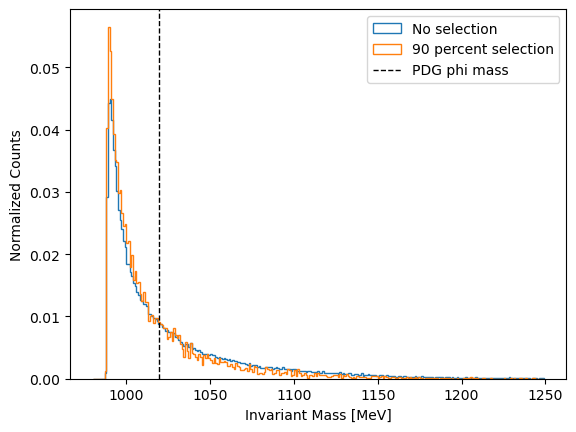

Epoch 50
-------------------------------
Classifier training loss: -2.288759
Adversary training loss: 2.302150
Classifier validation loss: -2.278319
Adversary validation loss: 2.308480
Diff score: 0.895118


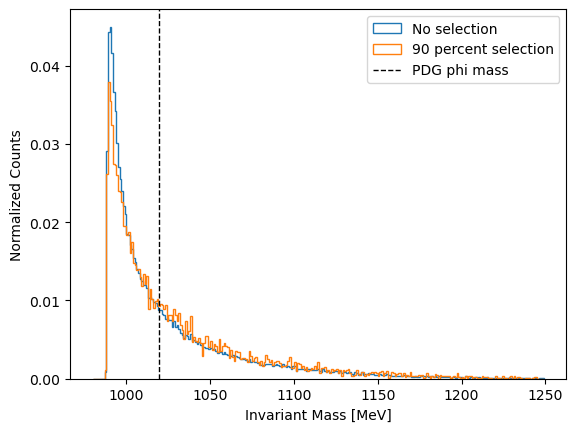

Done!


In [23]:


Training_losses_clas = np.array([])
Training_losses_adv = np.array([])
Validation_losses_clas = np.array([])
Validation_losses_adv = np.array([])
diff_scores = np.array([])


epochs = 50
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    
    # Train adversary and classifier
    E_clas_training_loss , E_adv_training_loss = mytools.train_full_orig(train_full_loader, final_classifier, final_adv, full_loss, lambda_, criterion_adv, optimizer_clas, optimizer_adv, scheduler_clas, scheduler_adv, 8, device, grad_clip = False)
    Training_losses_clas = np.append(Training_losses_clas, E_clas_training_loss)
    Training_losses_adv = np.append(Training_losses_adv, E_adv_training_loss)

    # Get validation losses
    E_clas_val_loss, E_adv_val_loss = mytools.validate_full(val_full_loader, final_classifier, final_adv, full_loss, lambda_, criterion_adv, device)
    Validation_losses_clas = np.append(Validation_losses_clas, E_clas_val_loss)
    Validation_losses_adv = np.append(Validation_losses_adv, E_adv_val_loss)

    # Get the diff_score
    df_test["Class_adv"] = mytools.test_clas(test_loader, final_classifier, device)
    df_bkg = df_test.loc[ (df_test.type == 'tritrig') | (df_test.type == 'wab')]
    per = np.percentile(df_bkg['Class_adv'],90)
    df_cut = df_bkg[df_bkg['Class_adv']>per].reset_index(drop=True)
    x1 = 1000*df_bkg.InvM.values
    x2 = 1000*df_cut.InvM.values
    diff_scores = np.append(diff_scores, mytools.get_diff_score(x1,x2) )

    print(f"Diff score: {diff_scores[-1]:>7f}")

    plt.figure()
    plt.hist(1000*df_bkg.InvM, bins=np.arange(980,1250,1), histtype='step', label='No selection', density=True)
    plt.hist(1000*df_cut.InvM, bins=np.arange(980,1250,1), histtype='step', label= '90 percent selection', density=True)
    plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
    plt.xlabel('Invariant Mass [MeV]')
    plt.ylabel('Normalized Counts')
    plt.legend()
    plt.show()

    # Keep a running copy of the model with the lowest loss
    if diff_scores[-1] == np.min(diff_scores):
        final_clas_adv = copy.deepcopy(final_classifier)
        final_adv_adv = copy.deepcopy(final_adv)

            
print("Done!")

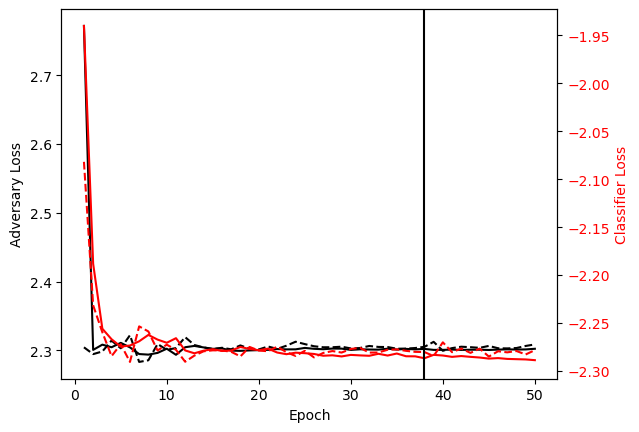

In [24]:
# Training Losses

fig, ax1 = plt.subplots()

best_epoch = np.argmin(diff_scores)+1



ax1.plot(np.arange(len(Training_losses_adv))+1, Training_losses_adv, 'k-', label='Training Adversary')
ax1.plot(np.arange(len(Validation_losses_adv))+1, Validation_losses_adv, 'k--', label='Validation Adversary')

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Adversary Loss', color='k')
ax1.tick_params(axis='y', labelcolor='k')

ax2 = ax1.twinx()

ax2.plot(np.arange(len(Training_losses_clas))+1, Training_losses_clas, 'r-', label='Training Classifier')
ax2.plot(np.arange(len(Validation_losses_clas))+1, Validation_losses_clas, 'r--', label='Validation Classifier')
ax2.axvline(best_epoch,label="Final model stopped here",color='k')

ax2.set_ylabel('Classifier Loss', color='r')
ax2.tick_params(axis='y', labelcolor='r')



Text(0.5, 0, 'Epoch')

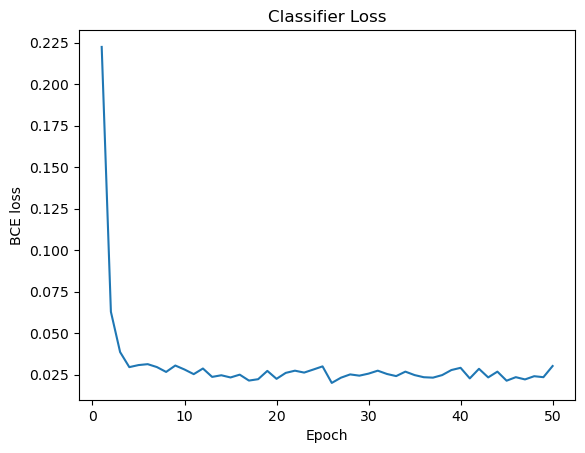

In [25]:
Validation_losses_clas+lambda_*Validation_losses_adv

plt.title("Classifier Loss")
plt.plot(np.arange(len(Training_losses_adv))+1, Validation_losses_clas+lambda_*Validation_losses_adv)
plt.ylabel("BCE loss")
plt.xlabel('Epoch')

Text(0.5, 0, 'Epoch')

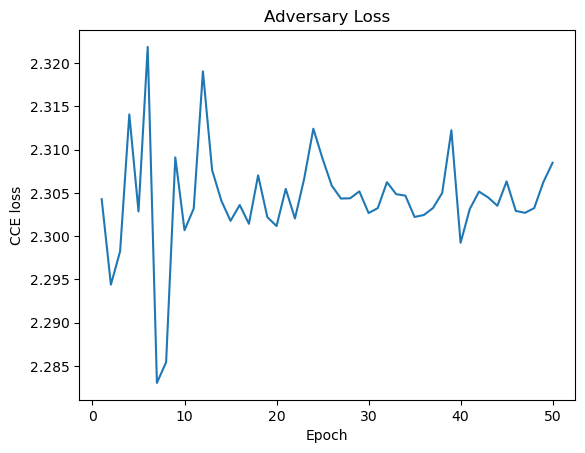

In [26]:
plt.title("Adversary Loss")
plt.plot(np.arange(len(Training_losses_adv))+1, Validation_losses_adv)
plt.ylabel("CCE loss")
plt.xlabel('Epoch')

## Test adversarially trained models

Test AUROC: 0.9971


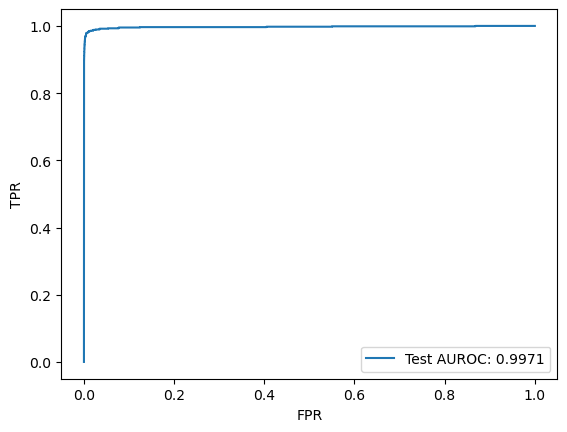

In [27]:
# Now test the pretrained model
test_pred = mytools.test_clas(test_loader, final_clas_adv, device)
test_pred=torch.sigmoid(torch.tensor(test_pred)).numpy()


fpr, tpr, thresholds = sklearn.metrics.roc_curve(y_test, test_pred, pos_label=1)
auc_test = sklearn.metrics.auc(fpr, tpr)
print(f'Test AUROC: {auc_test:0.4f}')

plt.plot(fpr, tpr, label=f'Test AUROC: {auc_test:0.4f}')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()

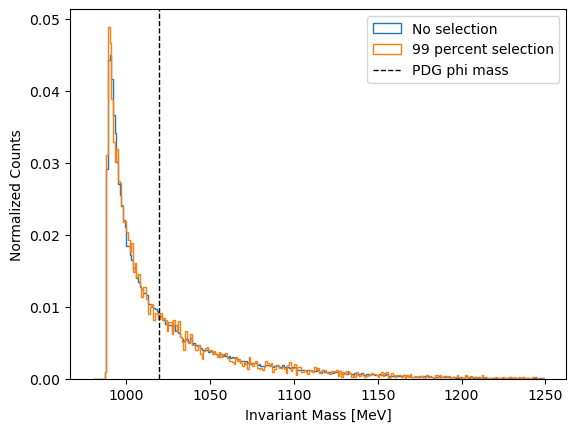

In [33]:
df_test["Class_adv"] = test_pred
df_bkg = df_test.loc[ (df_test.type == 'tritrig') | (df_test.type == 'wab')]
per = np.percentile(df_bkg['Class_adv'],90)
df_cut = df_bkg[df_bkg['Class_adv']>per].reset_index(drop=True)
x_vals = 1000*df_cut.InvM

plt.figure()
plt.hist(1000*df_bkg.InvM, bins=np.arange(980,1250,1), histtype='step', label='No selection', density=True)
plt.hist(x_vals, bins=np.arange(980,1250,1), histtype='step', label= '99 percent selection', density=True)
plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
plt.xlabel('Invariant Mass [MeV]')
plt.ylabel('Normalized Counts')
plt.legend()

In [34]:

x1 = 1000* df_bkg.InvM.values
x2 = 1000*df_cut.InvM.values

N, edges = np.histogram(x1, bins=np.arange(980,1250,1), density=False)
M, edges = np.histogram(x2, bins=np.arange(980,1250,1), density=False)

N2 = N[(N > 0) & (M > 0)]
M2 = M[(N > 0) & (M > 0)]

diff_score = np.mean( np.abs( N2/np.sum(N) - M2/np.sum(M) ) / np.sqrt( ( np.sqrt(N2)/np.sum(N) )**2 + ( np.sqrt(M2)/np.sum(M) )**2 ) )

print(diff_score)

N = len(df_test.loc[ ((df_test.type == 'tritrig') | (df_test.type == 'wab')) & (df_test.InvM < (1.019 + 0.01) )  & (df_test.InvM > (1.019 - 0.01) ) & ( df_test['Class_adv']>per ) ] )
S = len(df_test.loc[ (df_test.type == 'phiKK') & (df_test.InvM < (1.019 + 0.01) )  & (df_test.InvM > (1.019 - 0.01) ) & ( df_test['Class_adv']>per )  ] )

print(S/N)

0.7184199404742792
0.42993125330512955


Test AUROC: 0.9964


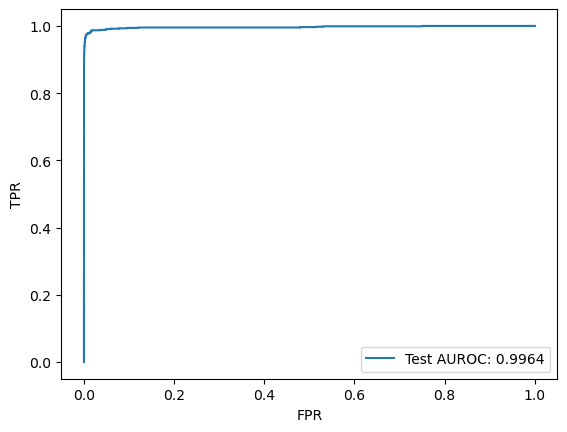

In [35]:
# Now test the pretrained model
test_pred = mytools.test_clas(test_loader, final_classifier, device)
test_pred=torch.sigmoid(torch.tensor(test_pred)).numpy()


fpr, tpr, thresholds = sklearn.metrics.roc_curve(y_test, test_pred, pos_label=1)
auc_test = sklearn.metrics.auc(fpr, tpr)
print(f'Test AUROC: {auc_test:0.4f}')

plt.plot(fpr, tpr, label=f'Test AUROC: {auc_test:0.4f}')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()

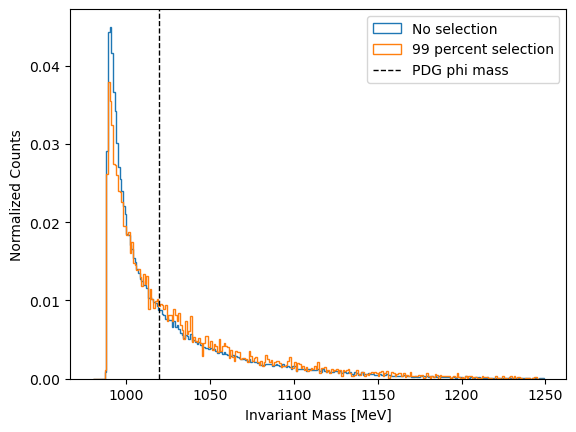

In [39]:
df_test["Class_adv"] = test_pred
df_bkg = df_test.loc[ (df_test.type == 'tritrig') | (df_test.type == 'wab')]
per = np.percentile(df_bkg['Class_adv'],90)
df_cut = df_bkg[df_bkg['Class_adv']>per].reset_index(drop=True)
x_vals = 1000*df_cut.InvM

plt.figure()
plt.hist(1000*df_bkg.InvM, bins=np.arange(980,1250,1), histtype='step', label='No selection', density=True)
plt.hist(x_vals, bins=np.arange(980,1250,1), histtype='step', label= '99 percent selection', density=True)
plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
plt.xlabel('Invariant Mass [MeV]')
plt.ylabel('Normalized Counts')
plt.legend()

In [40]:

x1 = 1000* df_bkg.InvM.values
x2 = 1000*df_cut.InvM.values

N, edges = np.histogram(x1, bins=np.arange(980,1250,1), density=False)
M, edges = np.histogram(x2, bins=np.arange(980,1250,1), density=False)

N2 = N[(N > 0) & (M > 0)]
M2 = M[(N > 0) & (M > 0)]

diff_score = np.mean(np.abs(N2/np.sum(N)-M2/np.sum(M)) / (np.sqrt(N2)/np.sum(N) + np.sqrt(M2)/np.sum(M) ))

print(diff_score)

N = len(df_test.loc[ ((df_test.type == 'tritrig') | (df_test.type == 'wab')) & (df_test.InvM < (1.019 + 0.01) )  & (df_test.InvM > (1.019 - 0.01) ) & ( df_test['Class_adv']>per ) ] )
S = len(df_test.loc[ (df_test.type == 'phiKK') & (df_test.InvM < (1.019 + 0.01) )  & (df_test.InvM > (1.019 - 0.01) ) & ( df_test['Class_adv']>per )  ] )

print(S/N)

0.7200899037829063
0.3980392156862745


In [59]:
# Save the adversarially trained models
#torch.save(final_clas_adv.state_dict(), "/Users/mghrear/data/ML_data/patch/classifier_adv_2021_v9_pass5_run"+str(run)+"_limited.pt")
#torch.save(final_adv_adv.state_dict(), "/Users/mghrear/data/ML_data/patch/adversary_adv_2021_v9_pass5_run"+str(run)+"_limited.pt")